In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix, roc_curve, auc, make_scorer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
import xgboost as xgb

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

import lightgbm as lgb


pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/jricardobt1/UofC/main/DATA607/Project/dataset.csv')

In [3]:
#Dropping columns with unique values - Country, State, City, Quarter
#Dropping columns with one value per customer - Latitude, Longitude, Population
#Dropping correlated columns - Satisfaction Score, Customer Status, Churn Reason

data = data.drop(['Customer ID','Country','State','City','Zip Code','Latitude','Longitude','Population','Quarter','Satisfaction Score','Customer Status','Churn Reason','Multiple Lines','Churn Category','Churn Score'],axis=1)
data['Churn Label'] = data['Churn Label'].map({'Yes':1,'No':0})

In [4]:
#Data Split and Preparation
# Split features and target

cat_cols = ['Gender','Under 30', 'Senior Citizen', 'Married', 'Dependents','Referred a Friend','Offer','Phone Service','Internet Service', 'Internet Type','Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies','Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing','Payment Method']
dummies = pd.get_dummies(data[cat_cols],drop_first=True)
scaler = StandardScaler()

numeric_cols = data.drop(columns=cat_cols + ['Churn Label']).columns
X_lr = pd.concat([data[numeric_cols], dummies], axis=1)
X_lr[numeric_cols] = scaler.fit_transform(X_lr[numeric_cols])
y_lr = data['Churn Label']

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

##### Logistic Regression

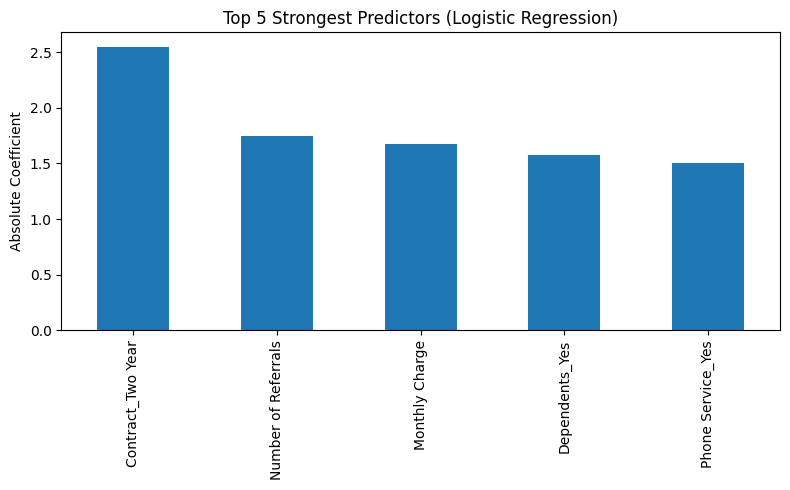

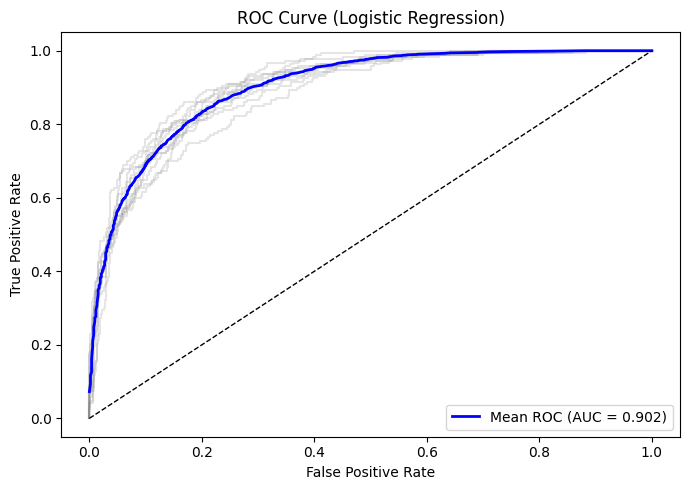

Confusion Matrix (Aggregated across folds, labels=[1, 0]):
 [[1256  613]
 [ 482 4692]]

Average F1 Score: 69.64%
Average Recall: 67.20%


In [5]:
model = LogisticRegression(max_iter=10000)

# Store results
f1_scores = []
recall_scores = []
coefs = []
fprs, tprs = [], []

# For final confusion matrix
all_y_true = []
all_y_pred = []

# Cross-validation loop
for train_idx, test_idx in kf.split(X_lr, y_lr):
    X_train, X_test = X_lr.iloc[train_idx], X_lr.iloc[test_idx]
    y_train, y_test = y_lr.iloc[train_idx], y_lr.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Collect for global confusion matrix
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    # Per-fold metrics
    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    coefs.append(model.coef_[0])  # binary classification

    # ROC curve points
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fprs.append(fpr)
    tprs.append(tpr)

# Aggregate Results
final_conf_matrix = confusion_matrix(all_y_true, all_y_pred, labels=[1, 0])
avg_f1 = np.mean(f1_scores) * 100  # %
avg_recall = np.mean(recall_scores) * 100  # %

# Feature importance (mean absolute coefficient)
coef_mean = np.mean(coefs, axis=0)
feature_importance = pd.Series(coef_mean, index=X_lr.columns).abs().sort_values(ascending=False).head(5)

#  Plot strongest predictors
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar')
plt.title("Top 5 Strongest Predictors (Logistic Regression)")
plt.ylabel("Absolute Coefficient")
plt.tight_layout()
plt.show()

#  Plot ROC Curve (mean)
plt.figure(figsize=(7, 5))
for i in range(len(fprs)):
    plt.plot(fprs[i], tprs[i], color='grey', alpha=0.2)  # individual folds
# Mean ROC curve
all_fpr = np.unique(np.concatenate([fpr for fpr in fprs]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(fprs)):
    mean_tpr += np.interp(all_fpr, fprs[i], tprs[i])
mean_tpr /= len(fprs)
plt.plot(all_fpr, mean_tpr, color='blue', label=f"Mean ROC (AUC = {auc(all_fpr, mean_tpr):.3f})", lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ===== Output =====
print("Confusion Matrix (Aggregated across folds, labels=[1, 0]):\n", final_conf_matrix)
print(f"\nAverage F1 Score: {avg_f1:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")


##### Decision Tree

Confusion Matrix (Aggregated across folds, labels=[1, 0]):
 [[1115  754]
 [ 808 4366]]

Average F1 Score: 58.80%
Average Recall: 59.66%


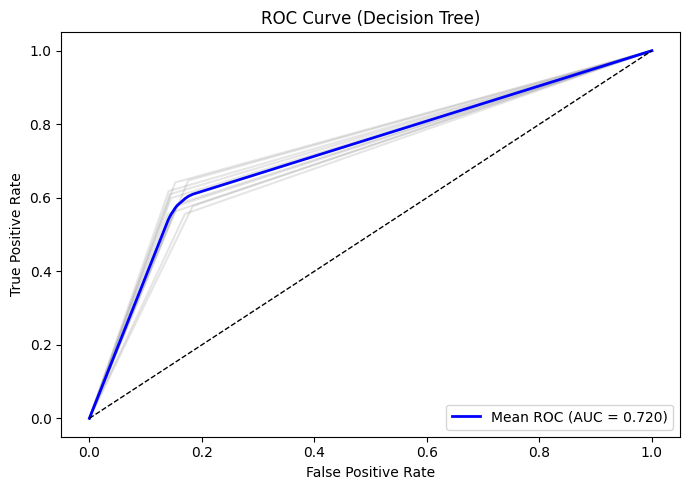

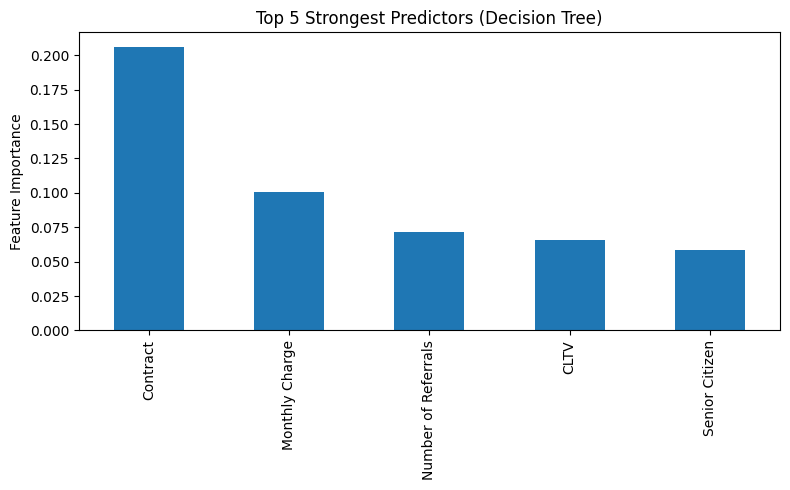

In [6]:
# Copy and preprocess data
X_dt = data.copy().drop(['Churn Label'], axis=1)
y_dt = data['Churn Label']

# Scale numerical features only
scaler = StandardScaler()
X_dt[numeric_cols] = scaler.fit_transform(X_dt[numeric_cols])

# Convert categorical columns to category dtype if not already
for col in cat_cols:
    if X_dt[col].dtype != 'category':
        X_dt[col] = X_dt[col].astype('category')

# Encode categories with label encoding
for col in cat_cols:
    X_dt[col] = X_dt[col].cat.codes

# Initialize model
model = DecisionTreeClassifier(random_state=42)

# Cross-validation setup
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

f1_scores = []
recall_scores_list = []
fprs, tprs = [], []

# For final confusion matrix
all_y_true = []
all_y_pred = []

# Cross-validation loop
for train_idx, test_idx in kf.split(X_dt, y_dt):
    X_train, X_test = X_dt.iloc[train_idx], X_dt.iloc[test_idx]
    y_train, y_test = y_dt.iloc[train_idx], y_dt.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Collect predictions
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    # Per-fold metrics
    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores_list.append(recall_score(y_test, y_pred))

    # ROC curve points
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fprs.append(fpr)
    tprs.append(tpr)

# Aggregate confusion matrix and mean scores
final_conf_matrix = confusion_matrix(all_y_true, all_y_pred, labels=[1, 0])
avg_f1 = np.mean(f1_scores) * 100
avg_recall = np.mean(recall_scores_list) * 100

print("Confusion Matrix (Aggregated across folds, labels=[1, 0]):\n", final_conf_matrix)
print(f"\nAverage F1 Score: {avg_f1:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")

# Plot ROC Curve (mean)
plt.figure(figsize=(7, 5))
for i in range(len(fprs)):
    plt.plot(fprs[i], tprs[i], color='grey', alpha=0.2)

all_fpr = np.unique(np.concatenate(fprs))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(fprs)):
    mean_tpr += np.interp(all_fpr, fprs[i], tprs[i])
mean_tpr /= len(fprs)

plt.plot(all_fpr, mean_tpr, color='blue', lw=2,
         label=f"Mean ROC (AUC = {auc(all_fpr, mean_tpr):.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Decision Tree)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Fit on full data to get feature importance
model.fit(X_dt, y_dt)
feature_importance = pd.Series(model.feature_importances_, index=X_dt.columns)
top5 = feature_importance.sort_values(ascending=False).head(5)

# Plot top 5 features
plt.figure(figsize=(8, 5))
top5.plot(kind='bar')
plt.title("Top 5 Strongest Predictors (Decision Tree)")
plt.ylabel("Feature Importance")
plt.tight_layout()
plt.show()


#### XGBoost

Fitting 10 folds for each of 9 candidates, totalling 90 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [19:33:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters (XGBoost): {'learning_rate': 0.1, 'max_depth': 5}
Best F1 Score (XGBoost): 0.7040


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [19:33:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [19:33:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [19:33:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [19:33:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [19:33:31] WARNING: /w


Confusion Matrix (Aggregated across folds, labels=[1, 0]):
 [[1249  620]
 [ 430 4744]]

Average F1 Score: 70.40%
Average Recall: 66.83%


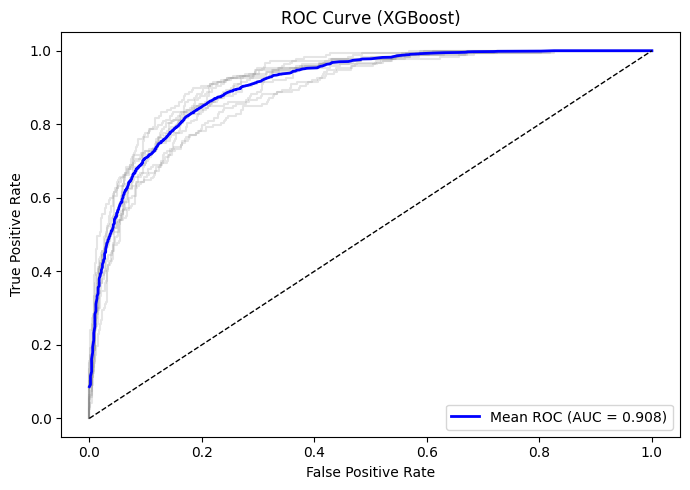

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [19:33:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


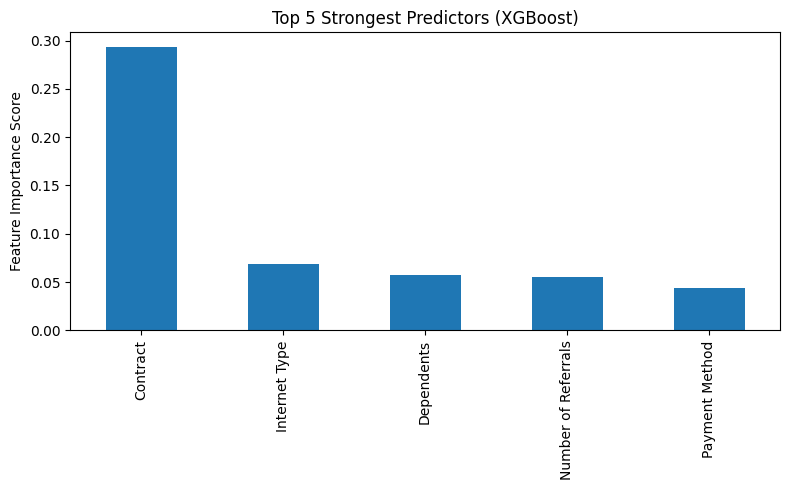

In [7]:
# Copy and preprocess data
X_xg = data.copy().drop(['Churn Label'], axis=1)
y_xg = data['Churn Label']

# Scale numerical columns
scaler = StandardScaler()
X_xg[numeric_cols] = scaler.fit_transform(X_xg[numeric_cols])

# Set categorical columns to category
for col in cat_cols:
    X_xg[col] = X_xg[col].astype('category')

# Initialize base model for Grid Search
base_model = xgb.XGBClassifier(
    enable_categorical=True,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Parameter grid for sweeping
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10]
}

# Stratified K-Fold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Use F1 score for evaluation
f1_scorer = make_scorer(f1_score)

# Grid Search for best params
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=kf,
    n_jobs=-1,
    verbose=2
)

# Fit grid search
grid_search.fit(X_xg, y_xg)

print("\nBest Parameters (XGBoost):", grid_search.best_params_)
print(f"Best F1 Score (XGBoost): {grid_search.best_score_:.4f}")

# Use best model for final evaluation
model_xg = grid_search.best_estimator_

# Metrics containers
f1_scores = []
recall_scores_list = []
fprs, tprs = [], []
all_y_true = []
all_y_pred = []

# Cross-validation loop with best model
for train_idx, test_idx in kf.split(X_xg, y_xg):
    X_train, X_test = X_xg.iloc[train_idx], X_xg.iloc[test_idx]
    y_train, y_test = y_xg.iloc[train_idx], y_xg.iloc[test_idx]

    model_xg.fit(X_train, y_train)
    y_pred = model_xg.predict(X_test)
    y_proba = model_xg.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores_list.append(recall_score(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fprs.append(fpr)
    tprs.append(tpr)

# Aggregate confusion matrix & mean scores
final_conf_matrix = confusion_matrix(all_y_true, all_y_pred, labels=[1, 0])
avg_f1 = np.mean(f1_scores) * 100
avg_recall = np.mean(recall_scores_list) * 100

print("\nConfusion Matrix (Aggregated across folds, labels=[1, 0]):\n", final_conf_matrix)
print(f"\nAverage F1 Score: {avg_f1:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")

# Plot ROC Curve (mean)
plt.figure(figsize=(7, 5))
for i in range(len(fprs)):
    plt.plot(fprs[i], tprs[i], color='grey', alpha=0.2)  # per-fold curves

all_fpr = np.unique(np.concatenate(fprs))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(fprs)):
    mean_tpr += np.interp(all_fpr, fprs[i], tprs[i])
mean_tpr /= len(fprs)

plt.plot(all_fpr, mean_tpr, color='blue', lw=2,
         label=f"Mean ROC (AUC = {auc(all_fpr, mean_tpr):.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (XGBoost)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Fit on full data to get feature importance
model_xg.fit(X_xg, y_xg)
feature_importance = pd.Series(model_xg.feature_importances_, index=X_xg.columns)
top5 = feature_importance.sort_values(ascending=False).head(5)

# Plot top 5 features
plt.figure(figsize=(8, 5))
top5.plot(kind='bar')
plt.title("Top 5 Strongest Predictors (XGBoost)")
plt.ylabel("Feature Importance Score")
plt.tight_layout()
plt.show()


#### Random Forest

Fitting 10 folds for each of 108 candidates, totalling 1080 fits

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score from Grid Search: 68.23%

Confusion Matrix (Aggregated across folds):
 [[4815  359]
 [ 715 1154]]
Average F1 Score: 68.23%


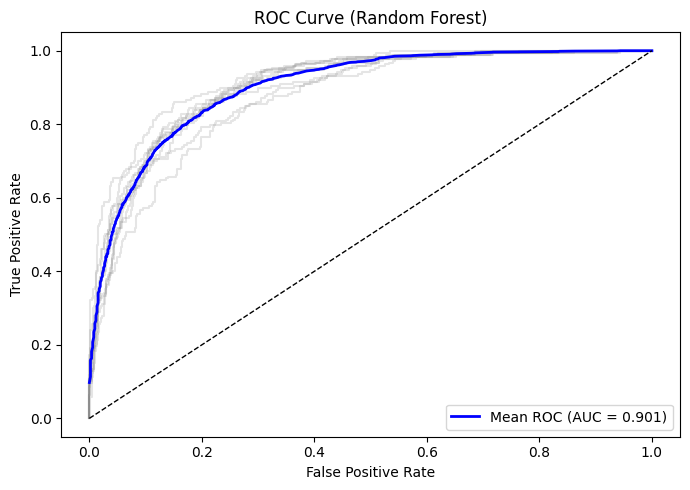


Top 5 Predictors:
 Contract               0.164123
Tenure in Months       0.093418
Number of Referrals    0.081944
Monthly Charge         0.070412
Total Revenue          0.063950
dtype: float64


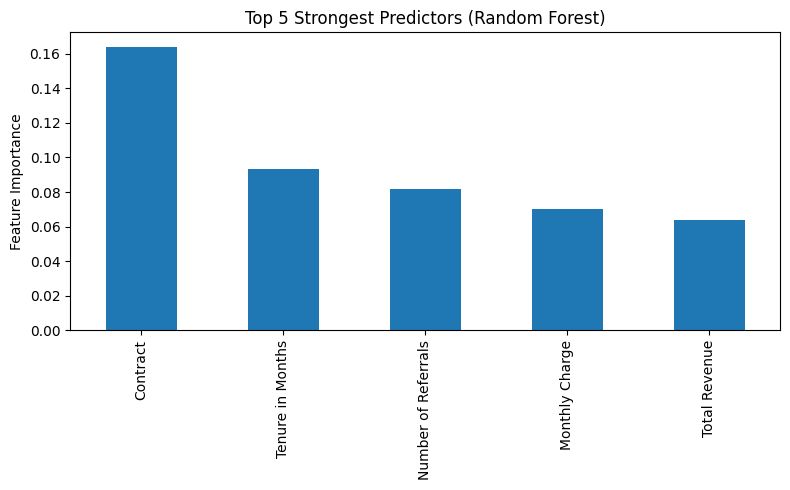

In [8]:
#  Prepare Data
X_rf = data.copy().drop(['Churn Label'], axis=1)
y_rf = data['Churn Label']

# Scale numerical features
scaler = StandardScaler()
X_rf[numeric_cols] = scaler.fit_transform(X_rf[numeric_cols])

# Encode categorical features as integer codes
for col in cat_cols:
    X_rf[col] = X_rf[col].astype('category').cat.codes

# Parameter Grid for GridSearch
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Grid Search with Stratified K-Fold
rf = RandomForestClassifier(random_state=42)
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=kf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_rf, y_rf)

print("\nBest Parameters:", grid_search.best_params_)
print(f"Best F1 Score from Grid Search: {grid_search.best_score_:.2%}")

# Cross-Validation Evaluation with Best Model
best_rf = grid_search.best_estimator_

conf_matrices = []
f1_scores = []
fprs, tprs = [], []

for train_idx, test_idx in kf.split(X_rf, y_rf):
    X_train, X_test = X_rf.iloc[train_idx], X_rf.iloc[test_idx]
    y_train, y_test = y_rf.iloc[train_idx], y_rf.iloc[test_idx]

    best_rf.fit(X_train, y_train)
    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:, 1]

    conf_matrices.append(confusion_matrix(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fprs.append(fpr)
    tprs.append(tpr)

# Aggregate metrics
avg_conf_matrix = sum(conf_matrices)
avg_f1 = np.mean(f1_scores) * 100

print("\nConfusion Matrix (Aggregated across folds):\n", avg_conf_matrix)
print(f"Average F1 Score: {avg_f1:.2f}%")

# Plot ROC Curve (Mean)
plt.figure(figsize=(7, 5))
for i in range(len(fprs)):
    plt.plot(fprs[i], tprs[i], color='grey', alpha=0.2)  # individual folds

all_fpr = np.unique(np.concatenate(fprs))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(fprs)):
    mean_tpr += np.interp(all_fpr, fprs[i], tprs[i])
mean_tpr /= len(fprs)

plt.plot(all_fpr, mean_tpr, color='blue', lw=2,
         label=f"Mean ROC (AUC = {auc(all_fpr, mean_tpr):.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Feature Importance
best_rf.fit(X_rf, y_rf)
feature_importance = pd.Series(best_rf.feature_importances_, index=X_rf.columns)
top5 = feature_importance.sort_values(ascending=False).head(5)

print("\nTop 5 Predictors:\n", top5)

plt.figure(figsize=(8, 5))
top5.plot(kind='bar')
plt.title("Top 5 Strongest Predictors (Random Forest)")
plt.ylabel("Feature Importance")
plt.tight_layout()
plt.show()


Fitting 10 folds for each of 9 candidates, totalling 90 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1869, number of negative: 5174
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2002
[LightGBM] [Info] Number of data points in the train set: 7043, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265370 -> initscore=-1.018243
[LightGBM] [Info] Start training from score -1.018243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

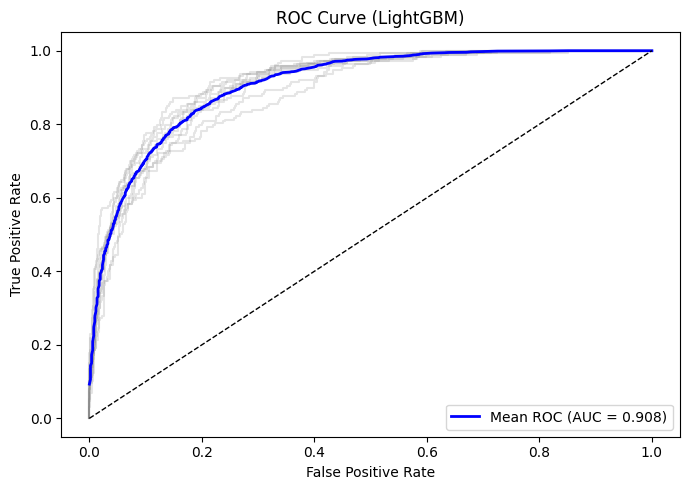

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1869, number of negative: 5174
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002215 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2002
[LightGBM] [Info] Number of data points in the train set: 7043, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265370 -> initscore=-1.018243
[LightGBM] [Info] Start training from score -1.018243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

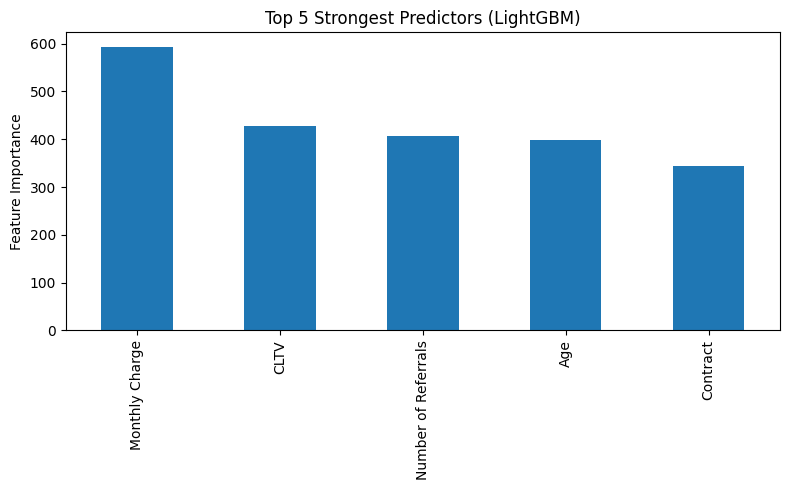

In [9]:

# Prepare Data
X_gbm = data.copy().drop(['Churn Label'], axis=1)
y_gbm = data['Churn Label']

# Scale only numerical columns
scaler = StandardScaler()
X_gbm[numeric_cols] = scaler.fit_transform(X_gbm[numeric_cols])

# Convert categorical columns to 'category' dtype (LightGBM can handle directly)
for col in cat_cols:
    X_gbm[col] = X_gbm[col].astype('category')

# Base LightGBM Model for Grid Search
base_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='binary_logloss',
    n_estimators=200,
    random_state=42
)

# Parameter Grid for Sweeping
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10]
}

# Setup Stratified K-Fold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Use F1 score for evaluation
f1_scorer = make_scorer(f1_score)

# Grid Search
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=kf,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_gbm, y_gbm, categorical_feature=cat_cols)

print("\nBest Parameters (LightGBM):", grid_search.best_params_)
print(f"Best F1 Score (LightGBM): {grid_search.best_score_:.4f}")

# Use Best Model for Final CV and Metrics
lgbm_model = grid_search.best_estimator_

f1_scores = []
recall_scores_list = []
fprs, tprs = [], []
all_y_true = []
all_y_pred = []

for train_idx, test_idx in kf.split(X_gbm, y_gbm):
    X_train, X_test = X_gbm.iloc[train_idx], X_gbm.iloc[test_idx]
    y_train, y_test = y_gbm.iloc[train_idx], y_gbm.iloc[test_idx]

    lgbm_model.fit(X_train, y_train, categorical_feature=cat_cols)
    y_pred = lgbm_model.predict(X_test)
    y_proba = lgbm_model.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores_list.append(recall_score(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fprs.append(fpr)
    tprs.append(tpr)

# Aggregate confusion matrix and mean scores
final_conf_matrix = confusion_matrix(all_y_true, all_y_pred, labels=[1, 0])
avg_f1 = np.mean(f1_scores) * 100
avg_recall = np.mean(recall_scores_list) * 100

print("Confusion Matrix (Aggregated across folds, labels=[1, 0]):\n", final_conf_matrix)
print(f"\nAverage F1 Score: {avg_f1:.2f}%")
print(f"Average Recall: {avg_recall:.2f}%")

# Plot ROC Curve (mean)
plt.figure(figsize=(7, 5))
for i in range(len(fprs)):
    plt.plot(fprs[i], tprs[i], color='grey', alpha=0.2)

all_fpr = np.unique(np.concatenate(fprs))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(fprs)):
    mean_tpr += np.interp(all_fpr, fprs[i], tprs[i])
mean_tpr /= len(fprs)

plt.plot(all_fpr, mean_tpr, color='blue', lw=2,
         label=f"Mean ROC (AUC = {auc(all_fpr, mean_tpr):.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LightGBM)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Feature Importance
lgbm_model.fit(X_gbm, y_gbm, categorical_feature=cat_cols)
importances = pd.Series(lgbm_model.feature_importances_, index=X_gbm.columns)
top5 = importances.sort_values(ascending=False).head(5)

print("\nTop 5 Predictors:\n", top5)

plt.figure(figsize=(8, 5))
top5.plot(kind='bar')
plt.title("Top 5 Strongest Predictors (LightGBM)")
plt.ylabel("Feature Importance")
plt.tight_layout()
plt.show()


In [11]:
pivot_table_churn_monthly_charge = data.pivot_table(values='Monthly Charge', index='Churn Label', aggfunc='mean')
print("Average Monthly Charge by Churn Label:")
display(pivot_table_churn_monthly_charge)

Average Monthly Charge by Churn Label:


,Monthly Charge
Churn Label,
0,61.265124
1,74.441332


In [13]:
pivot_table_churn_average_age = data.pivot_table(values='Age', index='Churn Label', aggfunc='mean')
print("Average Age by Churn Label:")
display(pivot_table_churn_average_age)

Average Age by Churn Label:


,Age
Churn Label,
0,45.344414
1,49.735688


In [14]:
pivot_table_number_of_referrals = data.pivot_table(values='Number of Referrals', index='Churn Label', aggfunc='mean')
print("Average Referrals by Churn Label:")
display(pivot_table_number_of_referrals)

Average Referrals by Churn Label:


,Number of Referrals
Churn Label,
0,2.468690
1,0.521134


Our goal is to understand the relationships between the predictors rather than having a black box model. The top 3 most important features for the best model (LightGBM) are Monthly Charge, Age and Number of Referrals. Combining the above tables help us understand what the most important predictors are why the customer left.  

In [15]:
combined_pivot_table = pd.concat([pivot_table_churn_monthly_charge, pivot_table_churn_average_age, pivot_table_number_of_referrals], axis=1)

print("Combined Pivot Table (Average Metrics by Churn Label):")
display(combined_pivot_table.T)

Combined Pivot Table (Average Metrics by Churn Label):


Churn Label,0,1
Monthly Charge,61.265124,74.441332
Age,45.344414,49.735688
Number of Referrals,2.468690,0.521134
